#                                  Multi Class Clasification - 3D

# Load Data

In [18]:
import pandas as pd
import os

In [19]:

file_name = "diabetes_dataset"
root_folder = f'multi-class-clasification/three-d/{file_name}/' 
os.makedirs(root_folder, exist_ok=True)

df = pd.read_csv('sample_data/'+file_name+'.csv')

#buang kolom tidak dibutuhkan
df.drop(columns=['diagnosed_diabetes'], inplace=True)

print("Sebulum DROP nan : " + str(df.shape) )
df = df.dropna() #Drop Nan
print("Setelah DROP nan : " + str(df.shape) )

#gabungkan data karena data kurang banyak
# gestational -> Type 2
df["diabetes_stage"] = df["diabetes_stage"].str.replace(
    r"(?i)gestational", "Type 2", regex=True
)
# Tipe 1 -> Type 2
df["diabetes_stage"] = df["diabetes_stage"].str.replace(
    r"(?i)Type 1", "Type 2", regex=True
)

Sebulum DROP nan : (100000, 30)
Setelah DROP nan : (100000, 30)


In [20]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,239,41,160,145,136,236,6.36,8.18,29.6,Type 2
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,213,66,99,36,118,195,5.07,7.51,44.7,Type 2
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,171,50,79,140,139,253,5.28,9.03,38.2,Type 2
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,210,52,125,160,137,184,12.74,7.20,23.5,Type 2


#### LabelEncoder

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#labeling
df['label_gender']            = le.fit_transform(df['gender'])
df['label_ethnicity']         = le.fit_transform(df['ethnicity'])
df['label_income_level']      = le.fit_transform(df['income_level'])
df['label_education_level']   = le.fit_transform(df['education_level'])
df['label_employment_status'] = le.fit_transform(df['employment_status'])
df['label_smoking_status']    = le.fit_transform(df['smoking_status'])

#label target
# Konversi ke kategori otomatis
df["diabetes_stage"] = df["diabetes_stage"].astype("category")

# Buat kolom label otomatis (0,1,2,3,...)
df["label_diabetes_stage"] = df["diabetes_stage"].cat.codes

labels = dict(enumerate(df["diabetes_stage"].cat.categories))
print(labels)


{0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Type 2'}


In [22]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hba1c,diabetes_risk_score,diabetes_stage,label_gender,label_ethnicity,label_income_level,label_education_level,label_employment_status,label_smoking_status,label_diabetes_stage
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,8.18,29.6,Type 2,1,0,2,1,0,2,2
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,5.63,23.0,No Diabetes,0,4,3,1,0,1,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,7.51,44.7,Type 2,1,2,3,1,3,2,2
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,9.03,38.2,Type 2,0,1,1,1,1,2,2
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,7.20,23.5,Type 2,1,4,3,0,1,2,2


#### Scaler

In [23]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Contoh: buat dan fit scaler
scaler = MinMaxScaler()
cols = [
    'label_gender', 
    'label_ethnicity', 
    'label_income_level',
    'label_education_level',
    'label_employment_status', 
    'label_smoking_status',
    #--------------------------
    'age',
    'physical_activity_minutes_per_week',
    'diet_score',
    'sleep_hours_per_day',
    'glucose_postprandial',
    'insulin_level',
    'hba1c',
    'diabetes_risk_score'
]

# Dictionary untuk menyimpan hasil transformasi
scaled_data = {}

# Loop untuk setiap kolom
for col in cols:
    scaler = MinMaxScaler()
    df[[col]] = scaler.fit_transform(df[[col]])  # scaling per kolom
    joblib.dump(scaler, os.path.join(root_folder, f'scaler_{col}.pkl'))
    scaled_data[col] = scaler
    print(f"✅ Scaler for '{col}' saved as scaler_{col}.pkl")

print("\nAll individual scalers saved successfully!")

✅ Scaler for 'label_gender' saved as scaler_label_gender.pkl
✅ Scaler for 'label_ethnicity' saved as scaler_label_ethnicity.pkl
✅ Scaler for 'label_income_level' saved as scaler_label_income_level.pkl
✅ Scaler for 'label_education_level' saved as scaler_label_education_level.pkl
✅ Scaler for 'label_employment_status' saved as scaler_label_employment_status.pkl
✅ Scaler for 'label_smoking_status' saved as scaler_label_smoking_status.pkl
✅ Scaler for 'age' saved as scaler_age.pkl
✅ Scaler for 'physical_activity_minutes_per_week' saved as scaler_physical_activity_minutes_per_week.pkl
✅ Scaler for 'diet_score' saved as scaler_diet_score.pkl
✅ Scaler for 'sleep_hours_per_day' saved as scaler_sleep_hours_per_day.pkl
✅ Scaler for 'glucose_postprandial' saved as scaler_glucose_postprandial.pkl
✅ Scaler for 'insulin_level' saved as scaler_insulin_level.pkl
✅ Scaler for 'hba1c' saved as scaler_hba1c.pkl
✅ Scaler for 'diabetes_risk_score' saved as scaler_diabetes_risk_score.pkl

All individual sc

In [24]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hba1c,diabetes_risk_score,diabetes_stage,label_gender,label_ethnicity,label_income_level,label_education_level,label_employment_status,label_smoking_status,label_diabetes_stage
0,0.555556,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,0.258103,0.57,...,0.720690,0.417054,Type 2,0.5,0.00,0.50,0.333333,0.000000,1.0,2
1,0.416667,Female,White,Highschool,Middle,Employed,Former,1,0.171669,0.67,...,0.281034,0.314729,No Diabetes,0.0,1.00,0.75,0.333333,0.000000,0.5,0
2,0.583333,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,0.068427,0.64,...,0.605172,0.651163,Type 2,0.5,0.50,0.75,0.333333,1.000000,1.0,2
3,0.777778,Female,Black,Highschool,Low,Retired,Never,0,0.058824,0.34,...,0.867241,0.550388,Type 2,0.0,0.25,0.25,0.333333,0.333333,1.0,2
4,0.388889,Male,White,Graduate,Middle,Retired,Never,1,0.130852,0.72,...,0.551724,0.322481,Type 2,0.5,1.00,0.75,0.000000,0.333333,1.0,2


#### Mapping label

In [25]:
import json
mapping_dicts = {}

cols = [
    'gender',
    'ethnicity',
    'education_level',
    'income_level',
    'employment_status',
    'smoking_status'
]

for col in cols:
    label_col = f"label_{col}"
    mapping_dicts[col] = dict(zip(df[col], df[label_col]))


with open(root_folder + 'label_mappings.json', 'w') as f:
    json.dump(mapping_dicts, f, indent=2)

rows = []
for col, mapping in mapping_dicts.items():
    for k, v in mapping.items():
        rows.append({'feature': col, 'original_value': k, 'label_value': v})

mapping_table = pd.DataFrame(rows)
mapping_table

,feature,original_value,label_value
0,gender,Male,0.500000
1,gender,Female,0.000000
2,gender,Other,1.000000
3,ethnicity,Asian,0.000000
4,ethnicity,White,1.000000
5,ethnicity,Hispanic,0.500000
6,ethnicity,Black,0.250000
7,ethnicity,Other,0.750000
8,education_level,Highschool,0.333333
9,education_level,Graduate,0.000000


#### Select Kolom To Trian

In [26]:
col_target = 'label_diabetes_stage'
cols = [
    'label_gender', 
    'label_ethnicity', 
    'label_income_level',
    'label_education_level',
    'label_employment_status', 
    'label_smoking_status',
    #--------------------------
    'age',
    'physical_activity_minutes_per_week',
    'diet_score',
    'sleep_hours_per_day',
    'glucose_postprandial',
    'insulin_level',
    'hba1c',
    'diabetes_risk_score',
    #------------------------
    col_target
]
df = df[cols].copy()

In [27]:
df.head()

,label_gender,label_ethnicity,label_income_level,label_education_level,label_employment_status,label_smoking_status,age,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,label_diabetes_stage
0,0.5,0.00,0.50,0.333333,0.000000,1.0,0.555556,0.258103,0.57,0.700000,0.764977,0.144275,0.720690,0.417054,2
1,0.0,1.00,0.75,0.333333,0.000000,0.5,0.416667,0.171669,0.67,0.500000,0.368664,0.000000,0.281034,0.314729,0
2,0.5,0.50,0.75,0.333333,1.000000,1.0,0.583333,0.068427,0.64,1.000000,0.576037,0.101588,0.605172,0.651163,2
3,0.0,0.25,0.25,0.333333,0.333333,1.0,0.777778,0.058824,0.34,0.514286,0.843318,0.108537,0.867241,0.550388,2
4,0.5,1.00,0.75,0.000000,0.333333,1.0,0.388889,0.130852,0.72,0.628571,0.525346,0.355394,0.551724,0.322481,2


#### cek keseimbangan data

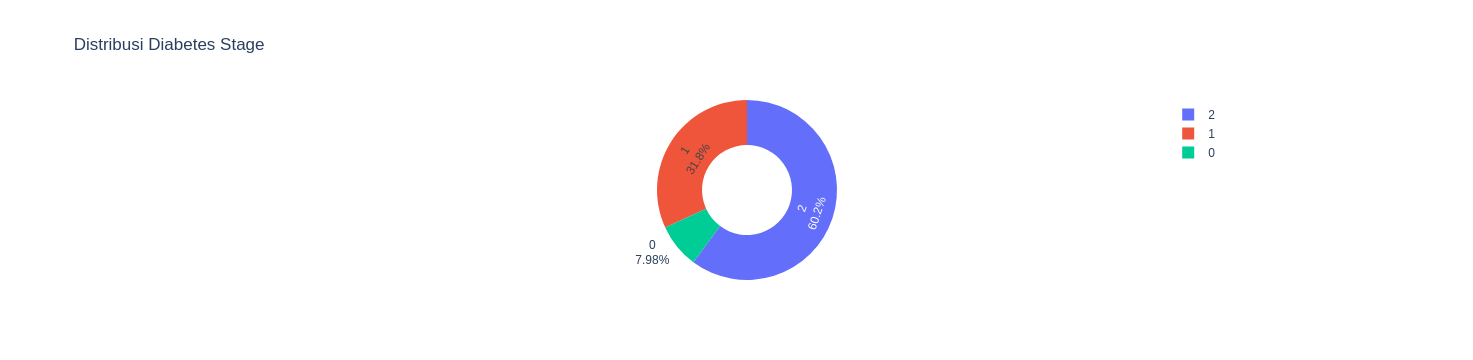

In [28]:
import plotly.express as px

fig = px.pie(
    df,
    names=col_target,
    hole=0.5,  # membuatnya jadi donat
    title='Distribusi Diabetes Stage',
)
fig.update_traces(textinfo='percent+label')
fig.show()

# Data Load To Train

#### select Future to traian

In [29]:
feature_1_cols = [
    'label_gender',
    'hba1c',
]
feature_2_cols = [
    'glucose_postprandial',
    'physical_activity_minutes_per_week',
]
feature_3_cols = [
    'age',
    'insulin_level',
]

target_cols  = col_target

#### Split data

In [30]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# Pisahkan train-test (stratify opsional jika masih punya kolom 'diabetes_stage')
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)


#### DataLoader

In [31]:
from data_set import MultiClass3DDataset

# Buat dataset dengan class kamu
train_dataset = MultiClass3DDataset(X_train, feature_1_cols,feature_2_cols,feature_3_cols, target_cols, normalize=False)
test_dataset  = MultiClass3DDataset(X_test,  feature_1_cols,feature_2_cols,feature_3_cols, target_cols, normalize=False)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Cek contoh batch
for X1,X2,X3, y in train_loader:
    print("X1 shape:", X1.shape)
    print("X2 shape:", X2.shape)
    print("X3 shape:", X3.shape)
    print("y  shape:", y.shape)
    print(X1[:3])  # contoh fitur
    print(X2[:3])  # contoh fitur
    print(X3[:3])  # contoh fitur
    print(y[:3])  # contoh label
    break

X1 shape: torch.Size([32, 2])
X2 shape: torch.Size([32, 2])
X3 shape: torch.Size([32, 2])
y  shape: torch.Size([32])
tensor([[0.0000, 0.2741],
        [0.0000, 0.3466],
        [0.0000, 0.4138]])
tensor([[0.2627, 0.0960],
        [0.2488, 0.4094],
        [0.3641, 0.1128]])
tensor([[0.6806, 0.2502],
        [0.6944, 0.2485],
        [0.4583, 0.0000]])
tensor([1, 2, 1])


# Config

In [32]:
from jcopdl.callback import Callback, set_config

config = set_config({
    "labels"         : labels,
    "feature_1_cols" : feature_1_cols,
    "feature_2_cols" : feature_2_cols,
    "feature_3_cols" : feature_3_cols,
    "input_1_dim"    : len(test_dataset.X1[0]),
    "input_2_dim"    : len(test_dataset.X2[0]),
    "input_3_dim"    : len(test_dataset.X3[0]),
    "hidden_1_dims"  : [ 8],
    "hidden_2_dims"  : [ 8],
    "hidden_3_dims"  : [ 8],
    "combine_dims"   : [4],
    "output_dim"     : len(labels),
    "dropout"        : 0.1,
    "activation"     : "relu",
    "early_stop_patience" : 5,
    "col_target"     : col_target,
})
config

Config(activation=relu, col_target=label_diabetes_stage, combine_dims=[4], dropout=0.1, early_stop_patience=5, feature_1_cols=['label_gender', 'hba1c'], feature_2_cols=['glucose_postprandial', 'physical_activity_minutes_per_week'], feature_3_cols=['age', 'insulin_level'], hidden_1_dims=[8], hidden_2_dims=[8], hidden_3_dims=[8], input_1_dim=2, input_2_dim=2, input_3_dim=2, labels={0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Type 2'}, output_dim=3)

# MCOC

#### Model - Criterion - Optimizer - Callback

In [34]:
from class_lib import Model3DPure
from torch import optim, nn
from jcopdl.callback import Callback
import torch.optim as optim

#Model
model = Model3DPure(
    input_dim_1  = config.input_1_dim, 
    input_dim_2  = config.input_2_dim, 
    input_dim_3  = config.input_3_dim, 
    hidden_dims_1= config.hidden_1_dims,
    hidden_dims_2= config.hidden_2_dims,
    hidden_dims_3= config.hidden_3_dims,
    combined_dims= config.combine_dims,
    output_dim   = config.output_dim,
    dropout=config.dropout, 
    activation=config.activation
).to(device)

#Criterion
criterion = nn.CrossEntropyLoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=0.1)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_adam  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

#### Visualisasi Model

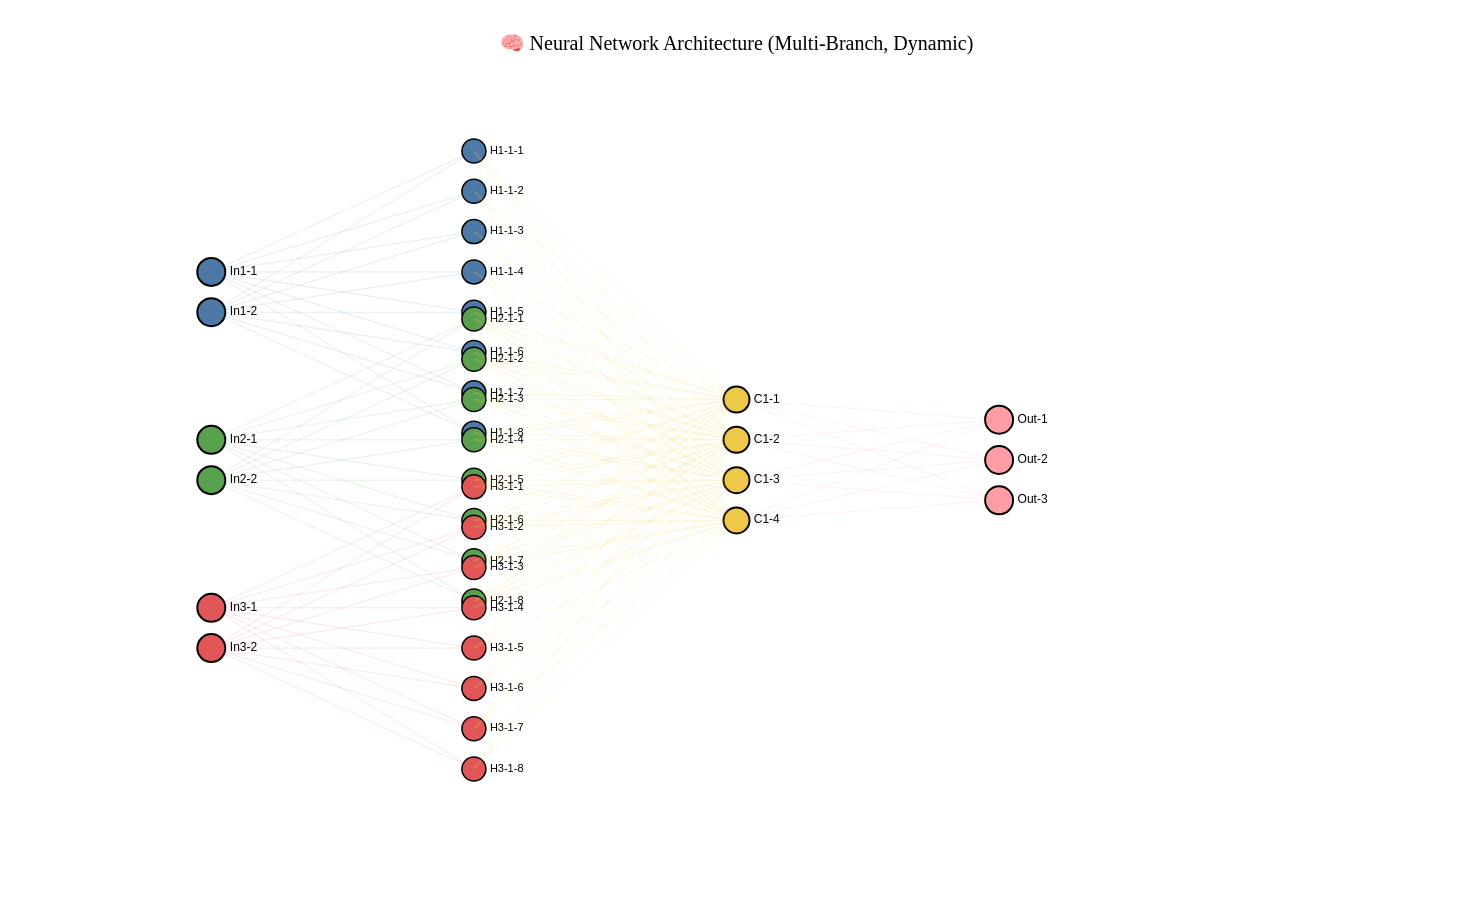

In [36]:
from visualization import plot_dynamic_multi_input_network
plot_dynamic_multi_input_network(
    input_dims=[config.input_1_dim, config.input_2_dim,config.input_3_dim],
    hidden_dims_per_branch=[
        config.hidden_1_dims,
        config.hidden_2_dims,
        config.hidden_3_dims
    ],
    combined_dims=config.combine_dims,
    output_dim=config.output_dim,
    figsize=(1000, 900)
)


# Training


─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1154.96it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.6599 │ 0.4842 │ │ No Diabetes  │  0.0000  │
│ Accuracy │ 0.6882 │ 0.7576 │ │ Pre-Diabetes │  0.6904  │
│ Macro F1 │ 0.4461 │ 0.5051 │ │    Type 2    │  0.8929  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

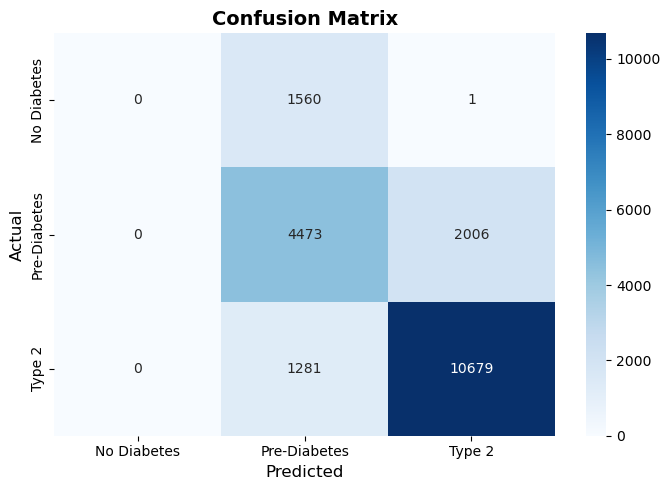


Epoch     1
Train_cost  = 0.6599 | Test_cost  = 0.4842 | Train_score = 0.6882 | Test_score = 0.7576 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1408.57it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.4919 │ 0.4152 │ │ No Diabetes  │  0.1127  │
│ Accuracy │ 0.7620 │ 0.7975 │ │ Pre-Diabetes │  0.8281  │
│ Macro F1 │ 0.5532 │ 0.6039 │ │    Type 2    │  0.8704  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

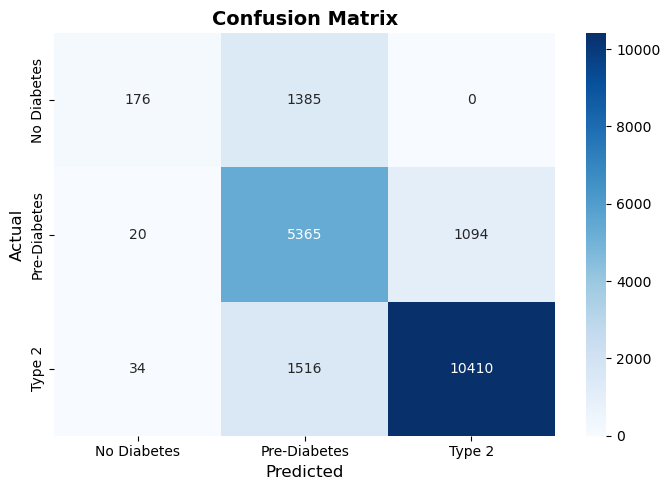


Epoch     2
Train_cost  = 0.4919 | Test_cost  = 0.4152 | Train_score = 0.7620 | Test_score = 0.7975 |


─────────────────────────────────────────────────── 🚀 EPOCH 3 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1079.29it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.4453 │ 0.3815 │ │ No Diabetes  │  0.4388  │
│ Accuracy │ 0.8015 │ 0.8351 │ │ Pre-Diabetes │  0.8938  │
│ Macro F1 │ 0.6974 │ 0.7381 │ │    Type 2    │  0.8550  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

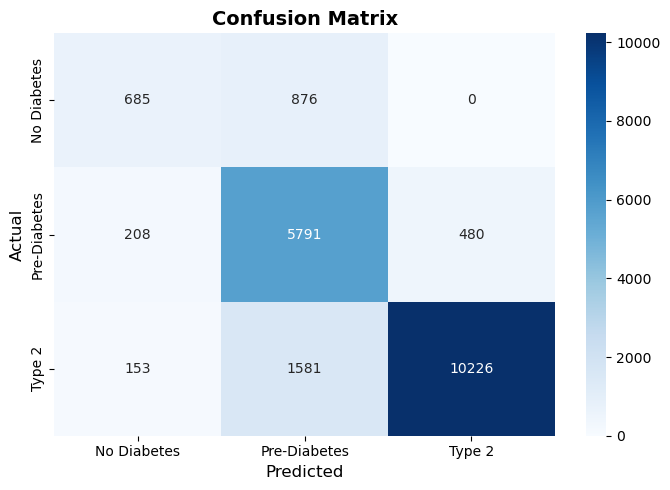


Epoch     3
Train_cost  = 0.4453 | Test_cost  = 0.3815 | Train_score = 0.8015 | Test_score = 0.8351 |


─────────────────────────────────────────────────── 🚀 EPOCH 4 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 977.74it/s] 


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.4151 │ 0.3626 │ │ No Diabetes  │  0.5612  │
│ Accuracy │ 0.8159 │ 0.8458 │ │ Pre-Diabetes │  0.9012  │
│ Macro F1 │ 0.7342 │ 0.7675 │ │    Type 2    │  0.8529  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

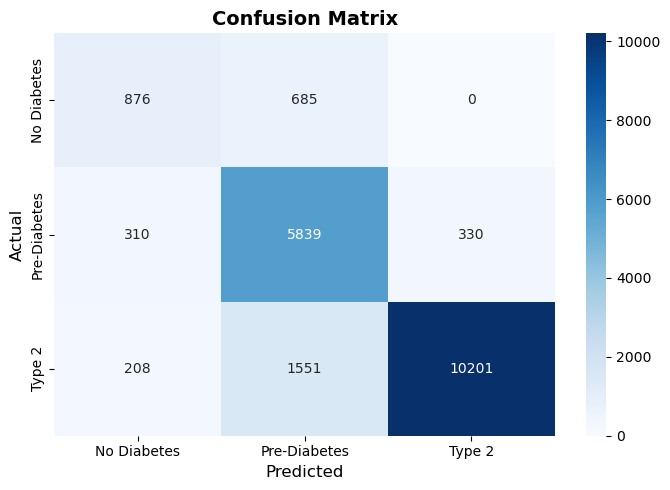


Epoch     4
Train_cost  = 0.4151 | Test_cost  = 0.3626 | Train_score = 0.8159 | Test_score = 0.8458 |


─────────────────────────────────────────────────── 🚀 EPOCH 5 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1273.27it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3958 │ 0.3518 │ │ No Diabetes  │  0.5291  │
│ Accuracy │ 0.8219 │ 0.8426 │ │ Pre-Diabetes │  0.8960  │
│ Macro F1 │ 0.7468 │ 0.7588 │ │    Type 2    │  0.8545  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

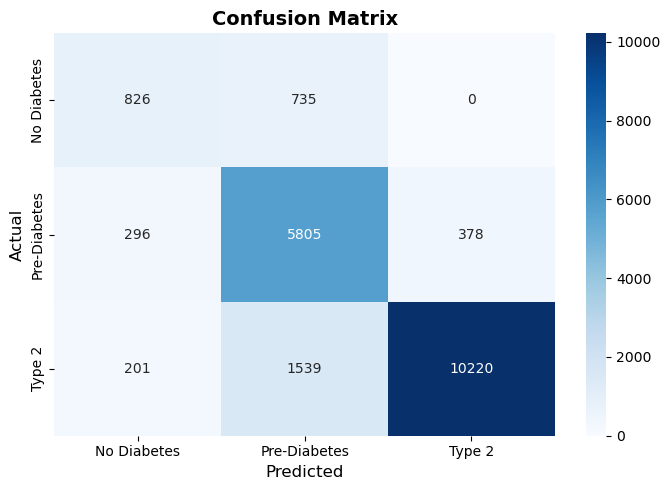


Epoch     5
Train_cost  = 0.3958 | Test_cost  = 0.3518 | Train_score = 0.8219 | Test_score = 0.8426 |
==> EarlyStop patience =  1 | Best test_score: 0.8458


─────────────────────────────────────────────────── 🚀 EPOCH 6 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 956.73it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3851 │ 0.3444 │ │ No Diabetes  │  0.8373  │
│ Accuracy │ 0.8254 │ 0.8541 │ │ Pre-Diabetes │  0.8663  │
│ Macro F1 │ 0.7541 │ 0.7971 │ │    Type 2    │  0.8497  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

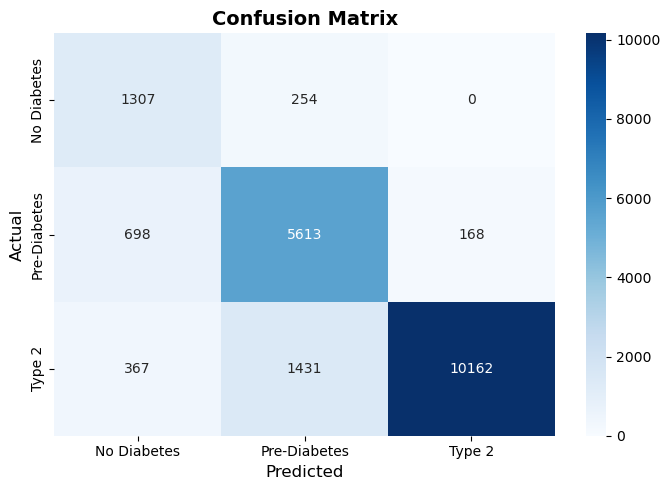


Epoch     6
Train_cost  = 0.3851 | Test_cost  = 0.3444 | Train_score = 0.8254 | Test_score = 0.8541 |


─────────────────────────────────────────────────── 🚀 EPOCH 7 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1187.55it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3779 │ 0.3398 │ │ No Diabetes  │  0.7431  │
│ Accuracy │ 0.8276 │ 0.8556 │ │ Pre-Diabetes │  0.8926  │
│ Macro F1 │ 0.7576 │ 0.7938 │ │    Type 2    │  0.8502  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

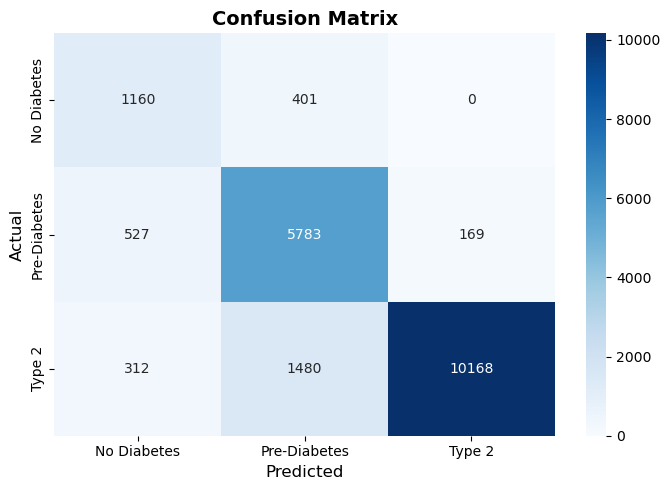


Epoch     7
Train_cost  = 0.3779 | Test_cost  = 0.3398 | Train_score = 0.8276 | Test_score = 0.8556 |


─────────────────────────────────────────────────── 🚀 EPOCH 8 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1046.13it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3742 │ 0.3368 │ │ No Diabetes  │  0.8559  │
│ Accuracy │ 0.8298 │ 0.8546 │ │ Pre-Diabetes │  0.8612  │
│ Macro F1 │ 0.7604 │ 0.7991 │ │    Type 2    │  0.8508  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

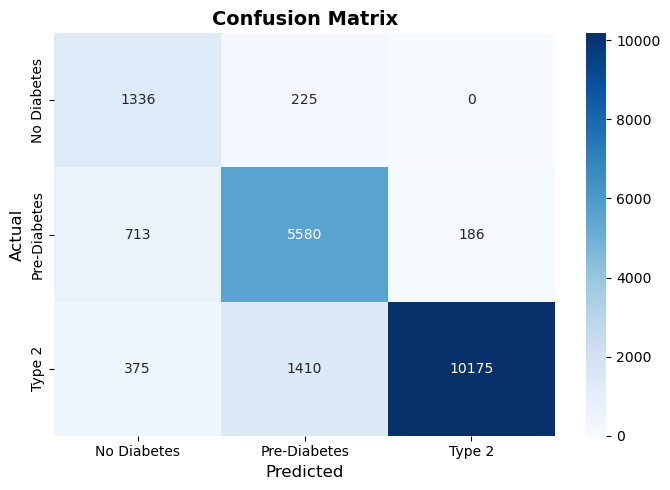


Epoch     8
Train_cost  = 0.3742 | Test_cost  = 0.3368 | Train_score = 0.8298 | Test_score = 0.8546 |
==> EarlyStop patience =  1 | Best test_score: 0.8556


─────────────────────────────────────────────────── 🚀 EPOCH 9 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1200.86it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3706 │ 0.3339 │ │ No Diabetes  │  0.7617  │
│ Accuracy │ 0.8310 │ 0.8565 │ │ Pre-Diabetes │  0.8907  │
│ Macro F1 │ 0.7625 │ 0.7973 │ │    Type 2    │  0.8503  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

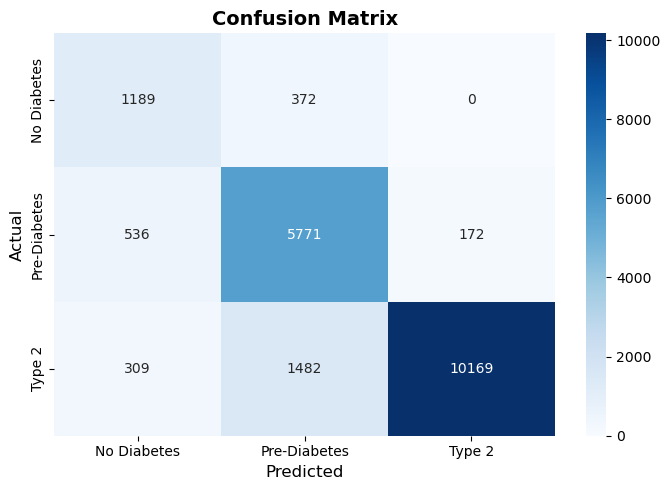


Epoch     9
Train_cost  = 0.3706 | Test_cost  = 0.3339 | Train_score = 0.8310 | Test_score = 0.8565 |


─────────────────────────────────────────────────── 🚀 EPOCH 10 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1148.84it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3678 │ 0.3348 │ │ No Diabetes  │  0.7809  │
│ Accuracy │ 0.8325 │ 0.8578 │ │ Pre-Diabetes │  0.8918  │
│ Macro F1 │ 0.7655 │ 0.7997 │ │    Type 2    │  0.8493  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

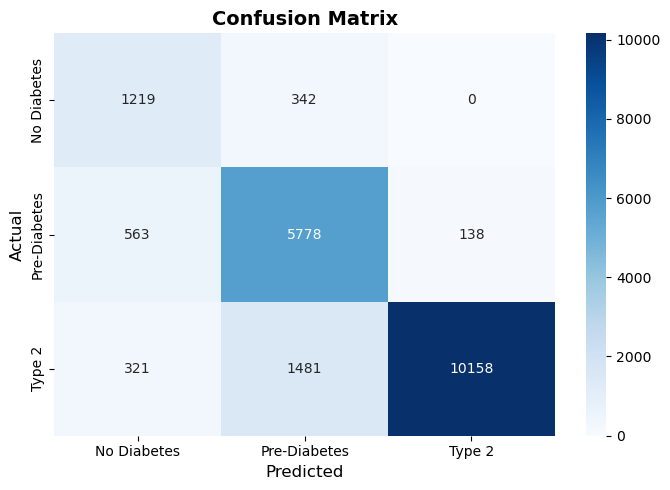


Epoch    10
Train_cost  = 0.3678 | Test_cost  = 0.3348 | Train_score = 0.8325 | Test_score = 0.8578 |


─────────────────────────────────────────────────── 🚀 EPOCH 11 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1255.63it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3667 │ 0.3332 │ │ No Diabetes  │  0.7956  │
│ Accuracy │ 0.8341 │ 0.8609 │ │ Pre-Diabetes │  0.9099  │
│ Macro F1 │ 0.7693 │ 0.8040 │ │    Type 2    │  0.8430  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

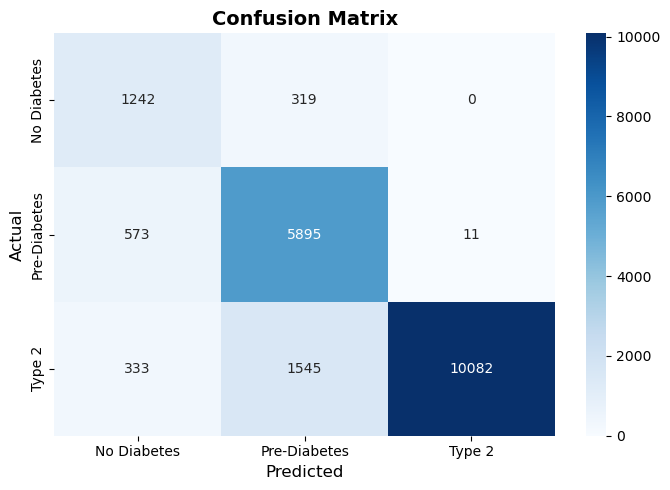


Epoch    11
Train_cost  = 0.3667 | Test_cost  = 0.3332 | Train_score = 0.8341 | Test_score = 0.8609 |


─────────────────────────────────────────────────── 🚀 EPOCH 12 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1174.65it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3646 │ 0.3333 │ │ No Diabetes  │  0.7822  │
│ Accuracy │ 0.8384 │ 0.8607 │ │ Pre-Diabetes │  0.9015  │
│ Macro F1 │ 0.7753 │ 0.8030 │ │    Type 2    │  0.8487  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

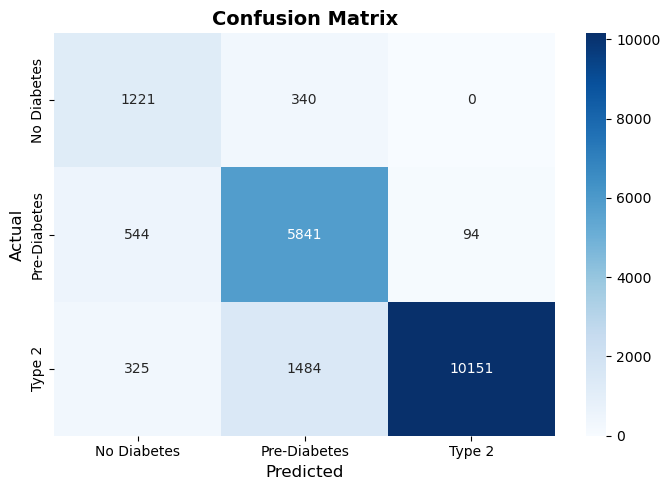


Epoch    12
Train_cost  = 0.3646 | Test_cost  = 0.3333 | Train_score = 0.8384 | Test_score = 0.8607 |
==> EarlyStop patience =  1 | Best test_score: 0.8609


─────────────────────────────────────────────────── 🚀 EPOCH 13 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1254.77it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3627 │ 0.3383 │ │ No Diabetes  │  0.8764  │
│ Accuracy │ 0.8391 │ 0.8559 │ │ Pre-Diabetes │  0.8849  │
│ Macro F1 │ 0.7782 │ 0.8029 │ │    Type 2    │  0.8375  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

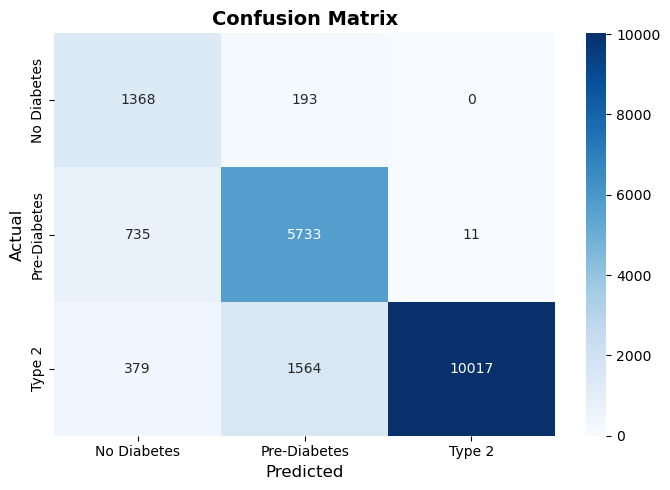


Epoch    13
Train_cost  = 0.3627 | Test_cost  = 0.3383 | Train_score = 0.8391 | Test_score = 0.8559 |
==> EarlyStop patience =  2 | Best test_score: 0.8609


─────────────────────────────────────────────────── 🚀 EPOCH 14 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1245.28it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3633 │ 0.3302 │ │ No Diabetes  │  0.8302  │
│ Accuracy │ 0.8388 │ 0.8576 │ │ Pre-Diabetes │  0.8788  │
│ Macro F1 │ 0.7773 │ 0.8017 │ │    Type 2    │  0.8496  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

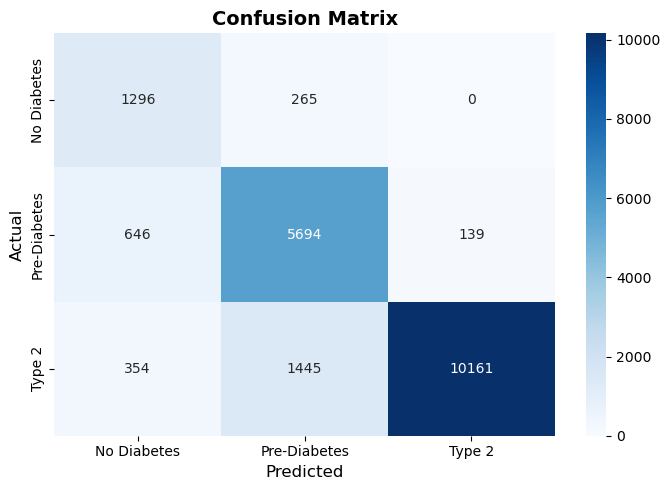


Epoch    14
Train_cost  = 0.3633 | Test_cost  = 0.3302 | Train_score = 0.8388 | Test_score = 0.8576 |
==> EarlyStop patience =  3 | Best test_score: 0.8609


─────────────────────────────────────────────────── 🚀 EPOCH 15 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1151.96it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3611 │ 0.3293 │ │ No Diabetes  │  0.7713  │
│ Accuracy │ 0.8396 │ 0.8620 │ │ Pre-Diabetes │  0.9100  │
│ Macro F1 │ 0.7779 │ 0.8047 │ │    Type 2    │  0.8478  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

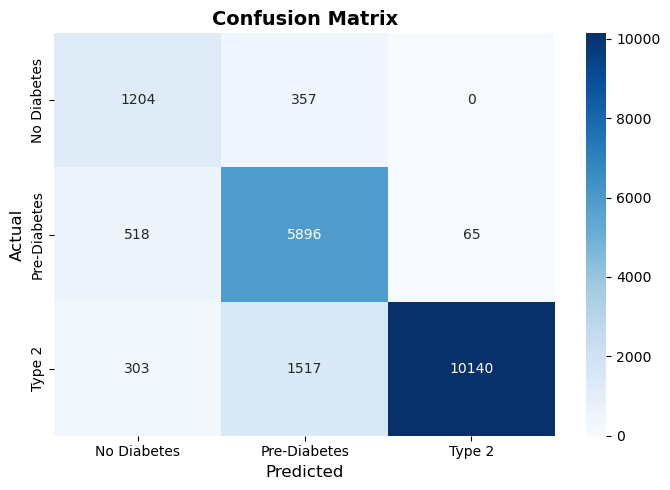


Epoch    15
Train_cost  = 0.3611 | Test_cost  = 0.3293 | Train_score = 0.8396 | Test_score = 0.8620 |


─────────────────────────────────────────────────── 🚀 EPOCH 16 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1113.52it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3600 │ 0.3301 │ │ No Diabetes  │  0.8776  │
│ Accuracy │ 0.8402 │ 0.8580 │ │ Pre-Diabetes │  0.8700  │
│ Macro F1 │ 0.7794 │ 0.8033 │ │    Type 2    │  0.8489  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

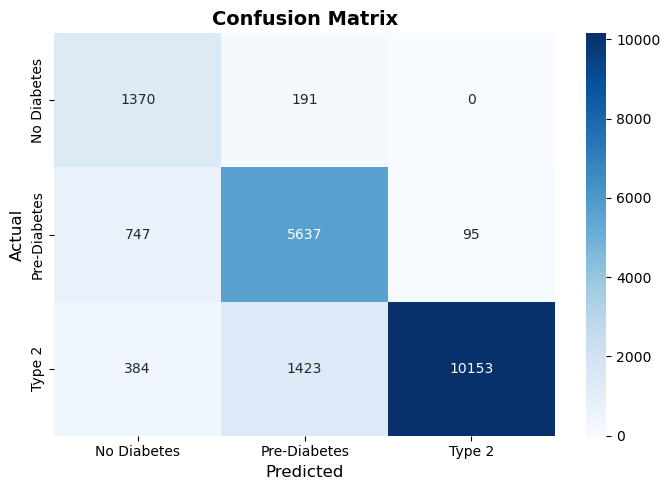


Epoch    16
Train_cost  = 0.3600 | Test_cost  = 0.3301 | Train_score = 0.8402 | Test_score = 0.8580 |
==> EarlyStop patience =  1 | Best test_score: 0.8620


─────────────────────────────────────────────────── 🚀 EPOCH 17 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1038.56it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3590 │ 0.3299 │ │ No Diabetes  │  0.8104  │
│ Accuracy │ 0.8408 │ 0.8606 │ │ Pre-Diabetes │  0.8955  │
│ Macro F1 │ 0.7798 │ 0.8037 │ │    Type 2    │  0.8482  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

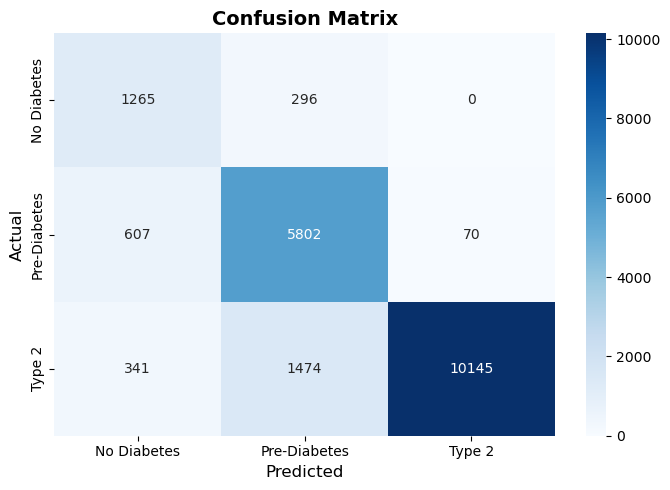


Epoch    17
Train_cost  = 0.3590 | Test_cost  = 0.3299 | Train_score = 0.8408 | Test_score = 0.8606 |
==> EarlyStop patience =  2 | Best test_score: 0.8620


─────────────────────────────────────────────────── 🚀 EPOCH 18 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1215.18it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3584 │ 0.3311 │ │ No Diabetes  │  0.9039  │
│ Accuracy │ 0.8425 │ 0.8566 │ │ Pre-Diabetes │  0.8586  │
│ Macro F1 │ 0.7819 │ 0.8029 │ │    Type 2    │  0.8492  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

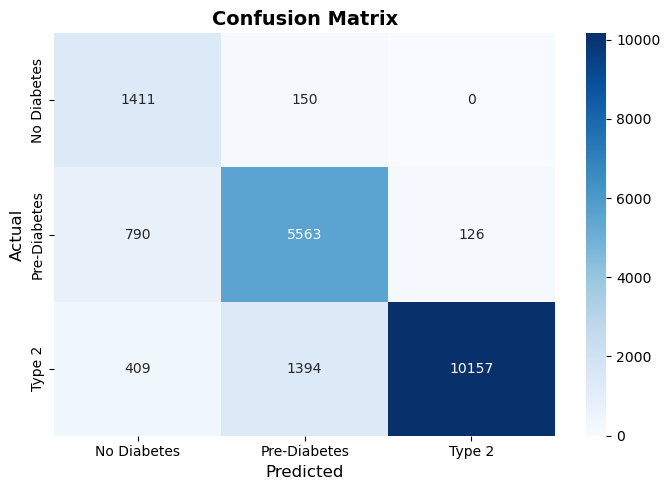


Epoch    18
Train_cost  = 0.3584 | Test_cost  = 0.3311 | Train_score = 0.8425 | Test_score = 0.8566 |
==> EarlyStop patience =  3 | Best test_score: 0.8620


─────────────────────────────────────────────────── 🚀 EPOCH 19 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1187.68it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3581 │ 0.3299 │ │ No Diabetes  │  0.7220  │
│ Accuracy │ 0.8429 │ 0.8584 │ │ Pre-Diabetes │  0.9074  │
│ Macro F1 │ 0.7837 │ 0.7974 │ │    Type 2    │  0.8497  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

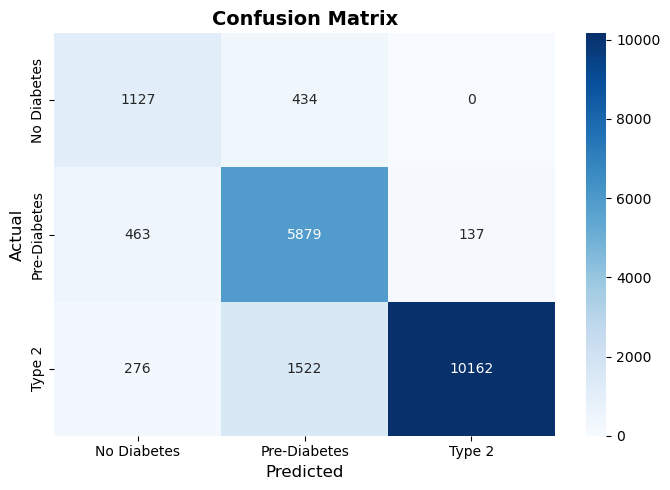


Epoch    19
Train_cost  = 0.3581 | Test_cost  = 0.3299 | Train_score = 0.8429 | Test_score = 0.8584 |
==> EarlyStop patience =  4 | Best test_score: 0.8620


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1374.52it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3586 │ 0.3304 │ │ No Diabetes  │  0.9084  │
│ Accuracy │ 0.8419 │ 0.8605 │ │ Pre-Diabetes │  0.8768  │
│ Macro F1 │ 0.7815 │ 0.8075 │ │    Type 2    │  0.8454  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

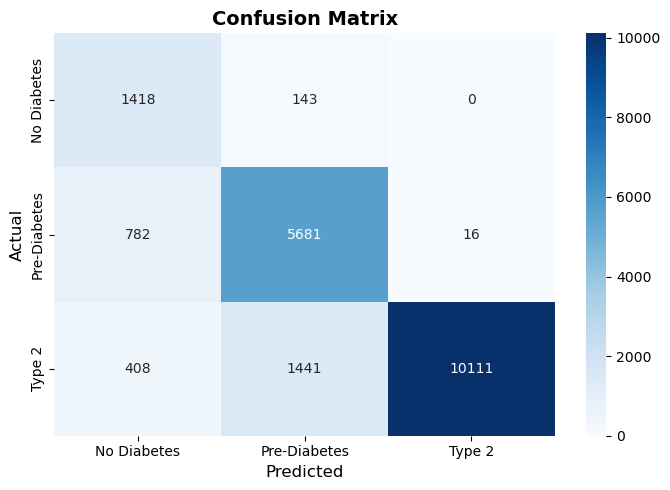


Epoch    20
Train_cost  = 0.3586 | Test_cost  = 0.3304 | Train_score = 0.8419 | Test_score = 0.8605 |


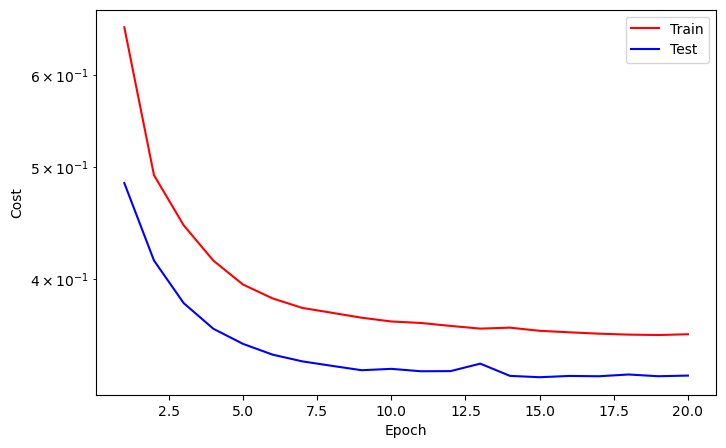

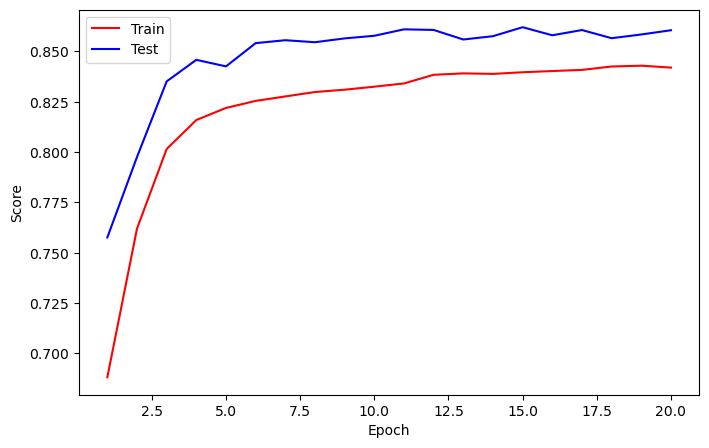

==> EarlyStop patience =  5 | Best test_score: 0.8620
==> Execute Early Stopping at epoch: 20 | Best test_score: 0.8620
==> Best model is saved at multi-class-clasification/three-d/diabetes_dataset/


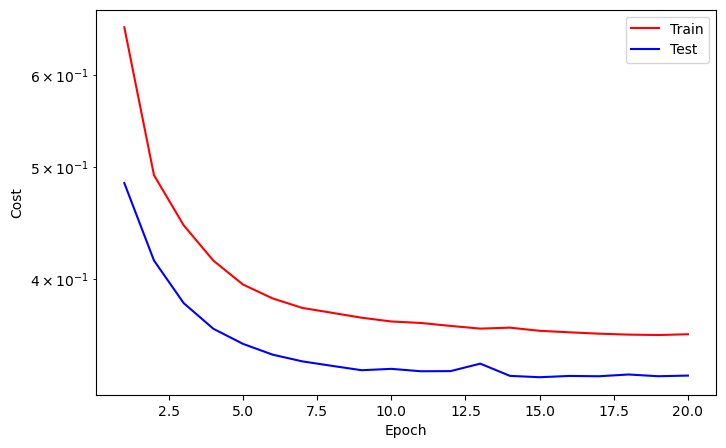

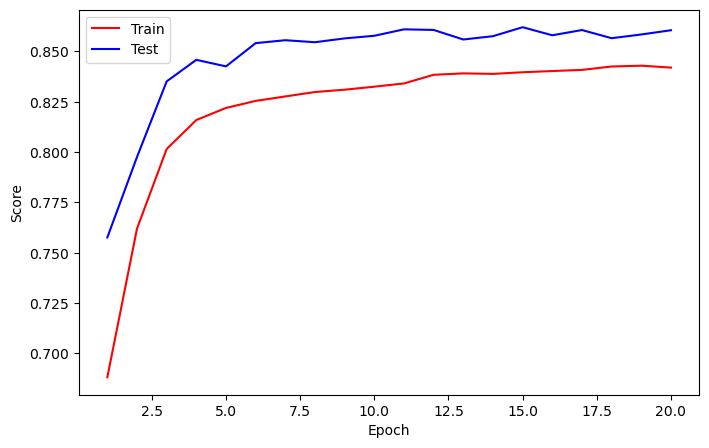

⏹️ Training dihentikan oleh early stopping.

In [37]:
from train_and_evaluate import train_and_evaluate_multi_class



train_and_evaluate_multi_class(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback,
    dimension='3d'
)

# Evaluate

      📊 Evaluasi Model           🎯 Per-Class Accuracy   
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metrik            ┃  Nilai ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ 💥 Loss (avg)     │ 0.3293 │ │ No Diabetes  │  0.7713  │
│ 🔹 Accuracy       │ 0.8620 │ │ Pre-Diabetes │  0.9100  │
│ 📈 Macro F1-score │ 0.8047 │ │    Type 2    │  0.8478  │
└───────────────────┴────────┘ └──────────────┴──────────┘

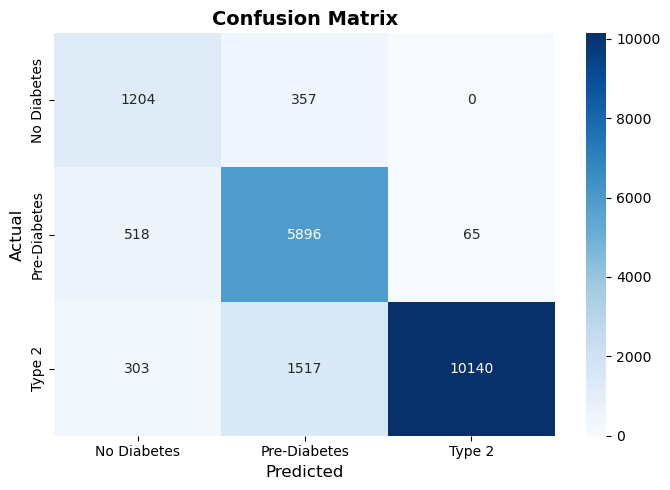

In [38]:
from evaluate import evaluate_multi_class
hsl = evaluate_multi_class(
    model=model,
    dataloader=test_loader,
    labels=labels,
    criterion=criterion,
    device=device,
    dimension='3d'
)

In [39]:
hsl['df'].head(200)

,Target,Prediksi,Prob (%),Benar (%),Benar
0,Type 2,Type 2,100.000000,100.000000,1
1,Pre-Diabetes,Pre-Diabetes,73.889999,73.889999,1
2,Pre-Diabetes,Pre-Diabetes,80.180000,80.180000,1
3,Type 2,Type 2,100.000000,100.000000,1
4,Type 2,Type 2,99.220001,99.220001,1
...,...,...,...,...,...
195,Type 2,Type 2,100.000000,100.000000,1
196,Type 2,Type 2,100.000000,100.000000,1
197,Type 2,Pre-Diabetes,78.820000,21.180000,0
198,Type 2,Type 2,94.589996,94.589996,1


# Pengaplikasian

In [90]:
#!pip install ipywidgets
#!jupyter nbextension enable --py widgetsnbextension

In [40]:
import torch, json
from torch import optim, nn
from class_lib import Model3DPure
import joblib
import pandas as pd


# Load Config
try:
    config = torch.load(root_folder + "configs.pth", map_location="cpu", weights_only=False)
except:
    config = torch.load(root_folder + "configs.pth", map_location="cpu")

#Load Weights
weights= torch.load(root_folder + "weights_best.pth", map_location="cpu")

#Load Label Mapping
with open(root_folder + "label_mappings.json", "r") as f:
    label_mapping = json.load(f)


model = Model3DPure(
    input_dim_1  = config.input_1_dim, 
    input_dim_2  = config.input_2_dim, 
    input_dim_3  = config.input_3_dim, 
    hidden_dims_1= config.hidden_1_dims,
    hidden_dims_2= config.hidden_2_dims,
    hidden_dims_3= config.hidden_3_dims,
    combined_dims= config.combine_dims,
    output_dim   = config.output_dim,
    dropout=config.dropout, 
    activation=config.activation
)
model.load_state_dict(weights)
model.eval() 

Model3DPure(
  (net1): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
  )
  (net2): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
  )
  (net3): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
  )
  (net_combined): Sequential(
    (0): Linear(in_features=24, out_features=4, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=4, out_features=3, bias=True)
  )
)

In [41]:
from aplokator import MultiClassPredictor


predictor = MultiClassPredictor(
    model=model,
    config=config,
    label_mapping=label_mapping,
    scaler_folder=root_folder,
    dimension="3d"
)

HTML(value='\n        <style>\n        .minimal-container { background: #f8f9fa; padding: 12px; border-radius:…